# Vectors: Arrows, Operations, and Length

**This notebook teaches vectors from scratch, no prior exposure is assumed.**

A single number can record one fact, a temperature, a count. But to describe a patient we need *several* numbers at once (age, blood pressure, a lab value), and to describe motion we need a direction as well as a size. A **vector** packages several numbers into one object. Geometrically it is an **arrow**; in data science it is a **list of features**. This notebook shows what vectors are, how to combine them, and how to measure their length.

## Learning objectives

- Read a vector as both an **arrow** (magnitude + direction) and a **column of numbers**.
- Add and subtract vectors (head-to-tail) and multiply by a scalar.
- Form **linear combinations** and use the unit vectors $\hat{\imath}, \hat{\jmath}$.
- Compute a vector's **magnitude** (length).

## Background

A **vector** is an ordered list of numbers, which we write **stacked in a column**:

$$\mathbf{v} = \begin{bmatrix} 3 \\ 4 \end{bmatrix}.$$

> **Notation.** Throughout this course vectors are written as columns, as in physics. A horizontal
> list like $[3, 4]$ means something different, a *row* vector, and rows are used only where they
> belong, namely when a row multiplies a column to form a dot product (the next notebook). Note also
> that Python prints a vector horizontally, as `[3 4]`; that is just how NumPy displays a flat list of
> numbers, and we use the display helper to show it the way we write it, as a column.

A vector has a **magnitude** (length) and a **direction**, and is drawn as an arrow from the origin. Operations are done component by component:

$$\mathbf{v} + \mathbf{w} = \begin{bmatrix} v_1 + w_1 \\ v_2 + w_2 \end{bmatrix}, \qquad c\,\mathbf{v} = \begin{bmatrix} c\,v_1 \\ c\,v_2 \end{bmatrix}.$$

A **linear combination** $a\mathbf{v} + b\mathbf{w}$ scales and adds. The **unit vectors**

$$\hat{\imath} = \begin{bmatrix} 1 \\ 0 \end{bmatrix}, \qquad \hat{\jmath} = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$$

point along the axes, and any 2D vector is $v_1\hat{\imath} + v_2\hat{\jmath}$. The **magnitude** comes from the Pythagorean theorem:

$$\|\mathbf{v}\| = \sqrt{v_1^2 + v_2^2 + \cdots}.$$

## This notebook covers

1. A vector as an arrow and as numbers.
2. Adding and subtracting (head-to-tail).
3. Scalar multiplication.
4. Linear combinations and unit vectors.
5. Magnitude.

**Prerequisites:** none, this notebook starts from scratch.

**Dataset:** none, vectors are entered directly (think of each as a patient's features).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers

# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# plotting helper: draw one vector as an arrow starting at `tail`
def arrow(ax, tail, vec, color, label=None, alpha=1.0):
    ax.quiver(tail[0], tail[1], vec[0], vec[1], angles="xy", scale_units="xy",
              scale=1, color=color, label=label, alpha=alpha, width=0.008)

## 1. A vector as an arrow and as numbers

The vector $\mathbf{v} = \begin{bmatrix} 3 \\ 4 \end{bmatrix}$ is the arrow from the origin $(0,0)$ to the point $(3, 4)$. Notice the two notations doing different jobs: $(3,4)$ with parentheses is a **point**, a location, while the column in brackets is the **vector** that reaches it. The same column could equally be a data point, say a patient with feature 1 = 3 and feature 2 = 4.

*(The arrow-drawing code is just graphics.)*

<IPython.core.display.Math object>

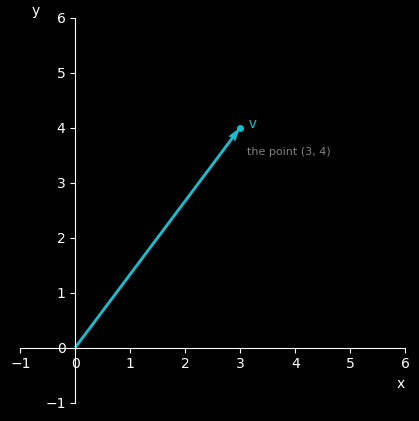

In [2]:
v = np.array([3, 4])
helpers.show(v, name="v")     # displayed as a column, the way we write it

# --- graphics: draw v as an arrow from the origin ---
fig, ax = plt.subplots(figsize=(5, 5))
ax.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1, color="tab:cyan")
ax.text(v[0], v[1], "  v", color="tab:cyan")
ax.plot(v[0], v[1], "o", color="tab:cyan", markersize=4)
ax.text(v[0], v[1] - 0.5, "  the point (3, 4)", color="gray", fontsize=8)
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-1, 6); ax.set_ylim(-1, 6); ax.set_aspect("equal")
plt.show()

## 2. Adding and subtracting

To add two vectors, add matching components. Geometrically this is **head-to-tail**: place $\mathbf{w}$'s tail at $\mathbf{v}$'s head, and $\mathbf{v} + \mathbf{w}$ runs from the origin to the final head. Think of it as *walking*: go along $\mathbf{v}$, then continue along $\mathbf{w}$; the sum is the single arrow from where you started to where you finished.

Subtraction is the same move with a flipped arrow: $\mathbf{v} - \mathbf{w} = \mathbf{v} + (-\mathbf{w})$. It has a second, very useful reading, drawn between the two heads, $\mathbf{v} - \mathbf{w}$ is the arrow that points *from* $\mathbf{w}$ *to* $\mathbf{v}$. (That is why the **distance** between two data points is the length of their difference, which we use in the next notebook.)

The two panels below show both.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

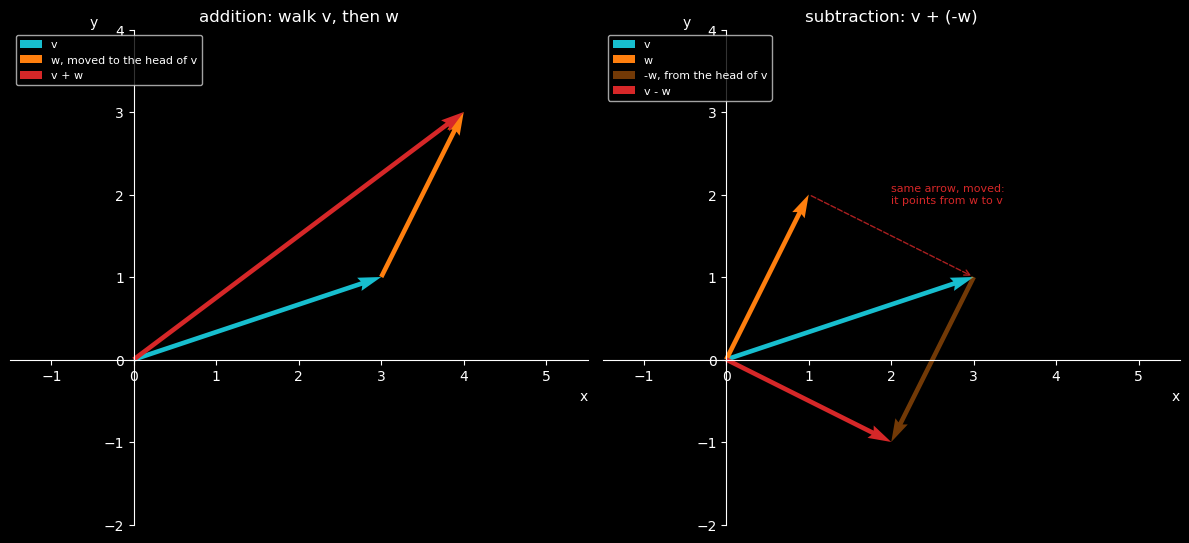

In [3]:
v = np.array([3, 1])
w = np.array([1, 2])

helpers.show(v + w, name="v + w")     # add component by component
helpers.show(v - w, name="v - w")

# --- graphics: head-to-tail addition (left) and subtraction (right) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# left panel: walk along v, then along w
ax = axes[0]
arrow(ax, (0, 0), v, "tab:cyan", "v")
arrow(ax, v, w, "tab:orange", "w, moved to the head of v")
arrow(ax, (0, 0), v + w, "tab:red", "v + w")
ax.set_title("addition: walk v, then w")

# right panel: subtracting w is adding the flipped arrow -w
ax = axes[1]
arrow(ax, (0, 0), v, "tab:cyan", "v")
arrow(ax, (0, 0), w, "tab:orange", "w")
arrow(ax, v, -w, "tab:orange", "-w, from the head of v", alpha=0.45)
arrow(ax, (0, 0), v - w, "tab:red", "v - w")
# the same difference, slid over to join the two heads
ax.annotate("", xy=(v[0], v[1]), xytext=(w[0], w[1]),
            arrowprops=dict(arrowstyle="->", color="tab:red", ls="--", alpha=0.8))
ax.text(2.0, 1.9, "same arrow, moved:\nit points from w to v", color="tab:red", fontsize=8)
ax.set_title("subtraction: v + (-w)")

for ax in axes:
    center_axes(ax)
    ax.set_xlabel("x", loc="right")
    ax.set_ylabel("y", loc="top", rotation=0)
    ax.set_xlim(-1.5, 5.5); ax.set_ylim(-2, 4); ax.set_aspect("equal")
    ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Scalar multiplication

Multiplying a vector by a number (a **scalar**) stretches it. A scalar bigger than 1 lengthens it, between 0 and 1 shrinks it, and a negative scalar flips it to point the opposite way. The key thing to see in the plot: every scaled copy lies on the **same dotted line through the origin**, scaling changes a vector's length, never its direction (except for the flip).

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

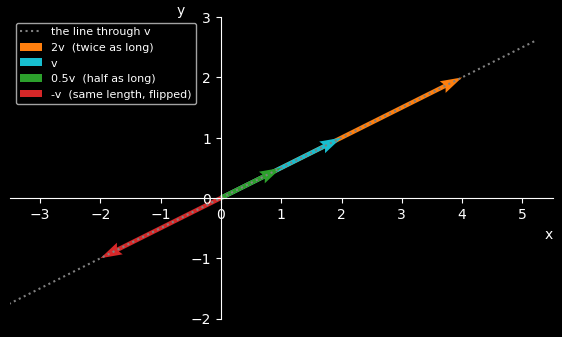

In [4]:
v = np.array([2, 1])
helpers.show(2 * v, name="2v")        # twice as long
helpers.show(0.5 * v, name="0.5v")    # half as long
helpers.show(-1 * v, name="-v")       # same length, opposite direction

# --- graphics: every multiple of v lands on one line through the origin ---
fig, ax = plt.subplots(figsize=(7, 5))
t = np.linspace(-1.8, 2.6, 2)
ax.plot(t * v[0], t * v[1], ":", color="gray", label="the line through v")

# longest first, so the shorter arrows stay visible on top of it
arrow(ax, (0, 0), 2 * v, "tab:orange", "2v  (twice as long)")
arrow(ax, (0, 0), v, "tab:cyan", "v")
arrow(ax, (0, 0), 0.5 * v, "tab:green", "0.5v  (half as long)")
arrow(ax, (0, 0), -v, "tab:red", "-v  (same length, flipped)")

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-3.5, 5.5); ax.set_ylim(-2, 3); ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
plt.show()

## 4. Linear combinations and unit vectors

Scaling two vectors and adding the results is a **linear combination** $a\mathbf{v} + b\mathbf{w}$. The special **unit vectors** $\hat{\imath} = \begin{bmatrix}1\\0\end{bmatrix}$ and $\hat{\jmath} = \begin{bmatrix}0\\1\end{bmatrix}$ build any 2D vector:

$$\begin{bmatrix}3\\4\end{bmatrix} = 3\begin{bmatrix}1\\0\end{bmatrix} + 4\begin{bmatrix}0\\1\end{bmatrix} = 3\hat{\imath} + 4\hat{\jmath}.$$

This is head-to-tail addition again, with the two pieces chosen to run along the axes: go 3 steps right, then 4 steps up. Seen this way, a vector's components *are* the recipe for building it out of $\hat{\imath}$ and $\hat{\jmath}$.

<IPython.core.display.Math object>

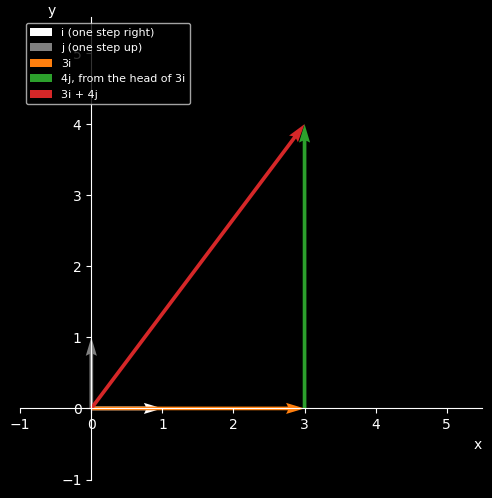

In [5]:
i_hat = np.array([1, 0])
j_hat = np.array([0, 1])

combo = 3 * i_hat + 4 * j_hat      # a linear combination
helpers.show(combo, name=r"3\hat{\imath} + 4\hat{\jmath}")

# --- graphics: build [3, 4] head-to-tail out of the unit vectors ---
fig, ax = plt.subplots(figsize=(6, 6))

# the unit vectors themselves, at the origin (length 1 each)
arrow(ax, (0, 0), i_hat, "white", "i (one step right)")
arrow(ax, (0, 0), j_hat, "gray", "j (one step up)")

# scaled and laid head-to-tail
arrow(ax, (0, 0), 3 * i_hat, "tab:orange", "3i")
arrow(ax, 3 * i_hat, 4 * j_hat, "tab:green", "4j, from the head of 3i")
arrow(ax, (0, 0), combo, "tab:red", "3i + 4j")

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-1, 5.5); ax.set_ylim(-1, 5.5); ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
plt.show()

## 5. Magnitude (length)

The **magnitude** $\|\mathbf{v}\|$ is the arrow's length. Drop a vertical line from the arrow's head down to the $x$-axis and you get a **right triangle** whose legs are exactly the vector's components, so the length is the hypotenuse, straight from the Pythagorean theorem:

$$\left\|\begin{bmatrix}3\\4\end{bmatrix}\right\| = \sqrt{3^2 + 4^2} = \sqrt{25} = 5.$$

The plot below draws that triangle. We compute the length by hand and with `np.linalg.norm`.

<IPython.core.display.Math object>

magnitude by hand = 5.0
np.linalg.norm(v) = 5.0


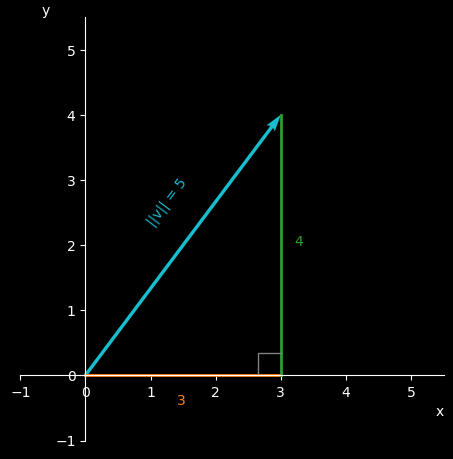

In [6]:
v = np.array([3, 4])
helpers.show(v, name="v")

# by hand: square the parts, add, square-root
magnitude = math.sqrt(v[0]**2 + v[1]**2)
print("magnitude by hand =", magnitude)
print("np.linalg.norm(v) =", np.linalg.norm(v))

# --- graphics: the vector is the hypotenuse of a right triangle ---
fig, ax = plt.subplots(figsize=(5.5, 5.5))
arrow(ax, (0, 0), v, "tab:cyan", "v")

ax.plot([0, v[0]], [0, 0], color="tab:orange", lw=2)          # horizontal leg, length 3
ax.plot([v[0], v[0]], [0, v[1]], color="tab:green", lw=2)     # vertical leg, length 4
ax.plot([2.65, 2.65, 3], [0, 0.35, 0.35], color="gray", lw=1)  # right-angle marker

ax.text(1.4, -0.45, "3", color="tab:orange")
ax.text(3.2, 2.0, "4", color="tab:green")
ax.text(0.9, 2.3, "||v|| = 5", color="tab:cyan", rotation=53)

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_xlim(-1, 5.5); ax.set_ylim(-1, 5.5); ax.set_aspect("equal")
plt.show()

## 6. Summary

- A **vector** is a **column** of numbers, drawn as an arrow with **magnitude** and **direction**.
- Add/subtract **component by component** (head-to-tail); a **scalar** stretches or flips it.
- A **linear combination** $a\mathbf{v} + b\mathbf{w}$ scales and adds; unit vectors $\hat{\imath},\hat{\jmath}$ build any vector.
- Magnitude $\|\mathbf{v}\| = \sqrt{\sum v_i^2}$.

Next: how two vectors relate through the **dot product** (`U2-2_Vectors-2_DotProductAndAngle`), and the one place a *row* vector is the natural thing to write.